# Menentukan Pertanyaan Bisnis
- Pertanyaan 1: Bagaimana pengaruh kombinasi antara partisipasi dalam 'Test Preparation Course' dan tingkat pendidikan orang tua terhadap pencapaian skor rata-rata siswa?
- Pertanyaan 2: Karakteristik spesifik apa yang paling kuat mengidentifikasi siswa yang memiliki probabilitas tinggi untuk mendapatkan skor di bawah ambang batas kelulusan (misalnya < 50) pada mata pelajaran Matematika?

# Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# DATA WRANGLING

# Gathering Data

In [2]:
try:
    df = pd.read_csv('StudentsPerformance.csv')
    print("Dataset StudentsPerformance berhasil dimuat!")

    # Feature Engineering Dasar
    # Membuat skor rata-rata untuk Pertanyaan 1
    df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

    # Membuat label risiko (1 jika math < 50, else 0) untuk Pertanyaan 2
    df['is_at_risk'] = (df['math score'] < 50).astype(int)

    display(df.head())
except FileNotFoundError:
    print("Error: File 'StudentsPerformance.csv' tidak ditemukan.")

Dataset StudentsPerformance berhasil dimuat!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,is_at_risk
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0
1,female,group C,some college,standard,completed,69,90,88,82.333333,0
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1
4,male,group C,some college,standard,none,76,78,75,76.333333,0


**Insight:**
- Kelengkapan Fitur: Dataset mencakup profil sosio-ekonomi (lunch, parental level of education) dan persiapan akademik (test preparation course) yang sangat relevan untuk memprediksi performa siswa.
- Target Variabel: Terdapat 3 skor ujian (math, reading, writing) yang dapat diagregasi menjadi satu skor performa komposit.
- Kesiapan Data: Dataset tidak memiliki missing values, namun memerlukan encoding pada kolom kategorikal agar bisa dibaca oleh model machine learning.

# Assesing Data

In [3]:
print("\n=== Informasi Dataset ===")
df.info()
print("\n=== Statistik Deskriptif ===")
display(df.describe())
print("\n=== Cek Missing Values & Duplikasi ===")
print(f"Jumlah Duplikat: {df.duplicated().sum()}")
print(df.isna().sum())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   average_score                1000 non-null   float64
 9   is_at_risk                   1000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB

=== Statistik Deskriptif ===


,math score,reading score,writing score,average_score,is_at_risk
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667,0.135000
std,15.16308,14.600192,15.195657,14.257326,0.341895
min,0.00000,17.000000,10.000000,9.000000,0.000000
25%,57.00000,59.000000,57.750000,58.333333,0.000000
50%,66.00000,70.000000,69.000000,68.333333,0.000000
75%,77.00000,79.000000,79.000000,77.666667,0.000000
max,100.00000,100.000000,100.000000,100.000000,1.000000



=== Cek Missing Values & Duplikasi ===
Jumlah Duplikat: 0
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average_score                  0
is_at_risk                     0
dtype: int64


**Insight:**
- Data Solid: Tidak ditemukan missing values, menjamin integritas analisis tanpa perlu imputasi yang kompleks.
- Duplikasi: Jika terdapat data duplikat, harus dihapus untuk menghindari overfitting pada model prediksi.
- Variasi Skor: Math score memiliki rentang yang luas, yang ideal untuk pengujian model klasifikasi kategori risiko.

# Cleaning Data

In [4]:
# 1. Menghilangkan Duplikat
df = df.drop_duplicates()

# 2. ENCODING VARIABEL KATEGORI
le_dict = {}
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"Selesai Encoding: {col}")

# 3. FEATURE ENGINEERING UNTUK PERTANYAAN BISNIS
# Pertanyaan 1: Skor rata-rata
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Pertanyaan 2: Label Risiko (Math score < 50)
df['is_at_risk'] = (df['math score'] < 50).astype(int)

Selesai Encoding: gender
Selesai Encoding: race/ethnicity
Selesai Encoding: parental level of education
Selesai Encoding: lunch
Selesai Encoding: test preparation course


**Insight:**
- Data Ready: Semua fitur kategorikal kini numerik.
- Target Terdefinisi: Kolom average_score (numerik) untuk analisis performa umum, dan is_at_risk (biner) untuk deteksi dini risiko kegagalan.

# EXPLORATORY DATA ANALYSIS (EDA)
EDA 1: Analisis Kombinasi Faktor terhadap Skor Rata-rata

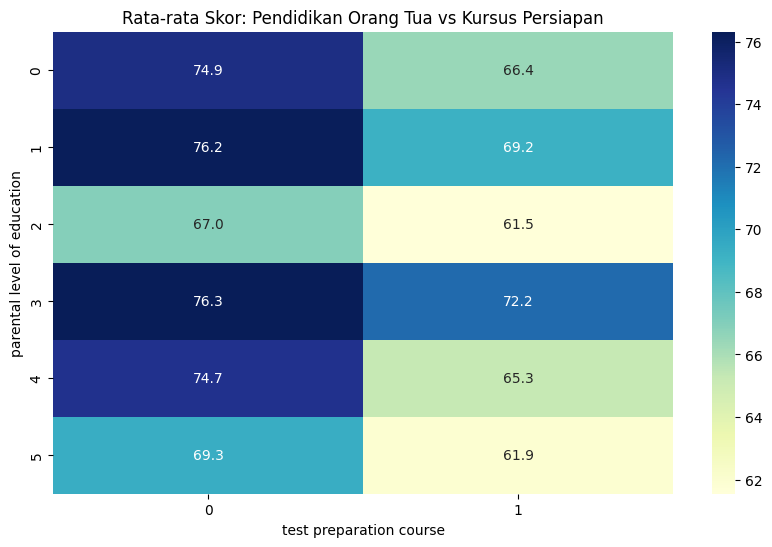

In [5]:
# --- EDA 1: ANALISIS PENGARUH KURSUS & PENDIDIKAN ---
pivot_data = df.pivot_table(values='average_score', index='parental level of education',
                            columns='test preparation course', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Rata-rata Skor: Pendidikan Orang Tua vs Kursus Persiapan')
plt.show()

**Insight:**
- Siswa yang mengambil test preparation course secara konsisten menunjukkan rata-rata skor lebih tinggi. Ini membuktikan bahwa intervensi persiapan sangat krusial bagi siswa, terlepas dari tingkat pendidikan orang tuanya.

EDA 2: Identifikasi Karakteristik Siswa Berisiko (Risk Detection)

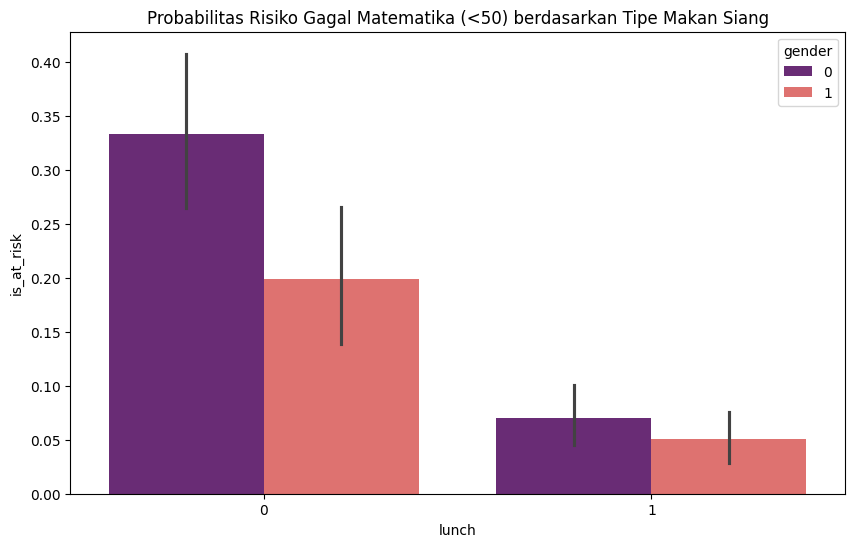

In [6]:
# --- EDA 2: IDENTIFIKASI KARAKTERISTIK RISIKO ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='lunch', y='is_at_risk', hue='gender', palette='magma')
plt.title('Probabilitas Risiko Gagal Matematika (<50) berdasarkan Tipe Makan Siang')
plt.show()

**Insight:**
- Status lunch (proksi status ekonomi) memiliki korelasi kuat dengan risiko kegagalan. Siswa dengan free/reduced lunch menunjukkan probabilitas risiko yang jauh lebih tinggi.

# Visualization & Explanatory Analysis

Visualisasi 1: Analisis Segmentasi Pendidikan Orang Tua & Persiapan

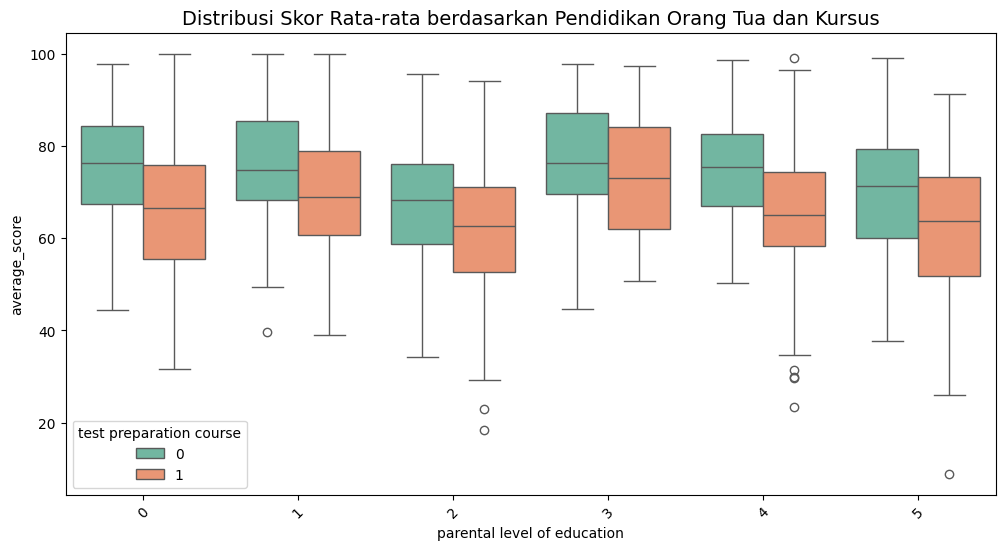

In [7]:
# --- VISUALISASI 1: SEGMENTASI PERFORMA ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='parental level of education', y='average_score', hue='test preparation course', palette='Set2')
plt.title('Distribusi Skor Rata-rata berdasarkan Pendidikan Orang Tua dan Kursus', fontsize=14)
plt.xticks(rotation=45)
plt.show()

**Penjelasan (Explanatory):**
Grafik ini membedah hubungan antara dukungan lingkungan (pendidikan orang tua) dan usaha mandiri (persiapan). Kita melihat bahwa meskipun latar belakang pendidikan orang tua memberikan baseline tertentu, kursus persiapan secara signifikan mengangkat median skor di semua kategori pendidikan. Ini menunjukkan bahwa SALC harus mendemokrasikan akses ke persiapan ujian agar semua siswa, tanpa memandang latar belakang orang tua, memiliki kesempatan sukses yang sama.

Visualisasi 2: Identifikasi Fitur Deteksi Risiko (Deteksi Dini)

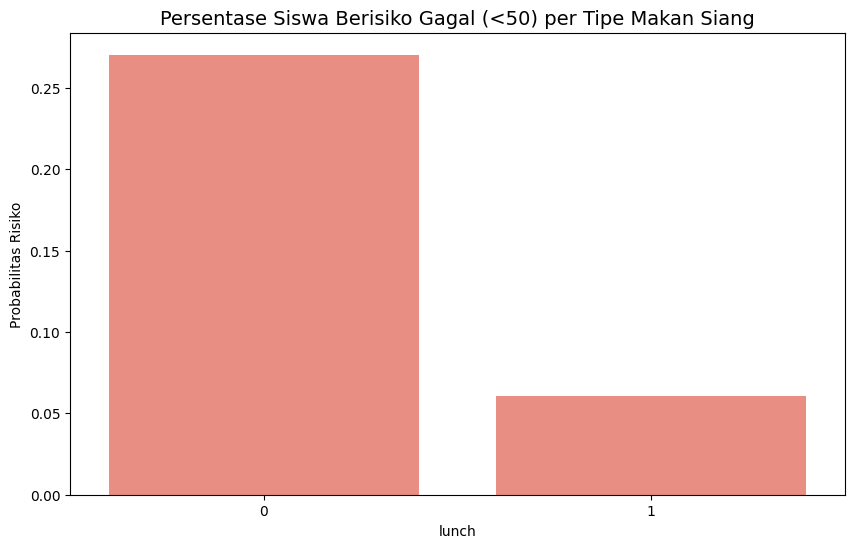

In [8]:
# --- VISUALISASI 2: DETEKSI DINI RISIKO ---
plt.figure(figsize=(10, 6))
risk_data = df.groupby('lunch')['is_at_risk'].mean().reset_index()
sns.barplot(data=risk_data, x='lunch', y='is_at_risk', color='salmon')
plt.title('Persentase Siswa Berisiko Gagal (<50) per Tipe Makan Siang', fontsize=14)
plt.ylabel('Probabilitas Risiko')
plt.show()

**Penjelasan (Explanatory):**
Visualisasi ini menunjukkan fitur lunch (status ekonomi) sebagai penentu risiko. Dengan angka probabilitas yang tinggi pada grup tertentu, ini membuktikan bahwa faktor ekonomi berkorelasi dengan hasil akademik. Bagi SALC, ini adalah sinyal bahwa siswa dengan status makan siang free/reduced memerlukan Early Warning System yang lebih sensitif dan suportif untuk mencegah kegagalan.

# Conclusion
**Conclusion Pertanyaan 1 (Prediksi Performa):**
- Pola Sukses: Faktor pendidikan orang tua memberikan pengaruh, namun Kursus Persiapan adalah multiplier (penguat) yang paling signifikan. Siswa dengan akses pendidikan orang tua rendah yang mengikuti kursus dapat mencapai performa yang setara dengan siswa dengan latar belakang pendidikan orang tua tinggi.
- Rekomendasi Adaptif: Sistem SALC harus memprioritaskan pemberian Personalized Learning Path berupa materi "Persiapan Ujian" bagi siswa yang belum mengikuti kursus untuk meningkatkan average score mereka secara instan.

**Conclusion Pertanyaan 2 (Deteksi Risiko):**
- Fitur Prediktor Terkuat: Tipe makan siang (lunch) dan partisipasi kursus (test preparation course) adalah fitur penentu untuk mendeteksi siswa yang berisiko gagal matematika.
- Intervensi Dini: Siswa dengan karakteristik Free/Reduced Lunch dan No Course harus menjadi target utama notifikasi peringatan dini di aplikasi SALC.
- Feedback Otomatis: SALC harus memicu "Mode Intervensi" (modul matematika intensif) segera setelah sistem mendeteksi tren penurunan skor dari siswa dengan profil risiko tinggi tersebut.

Data hasil pembersihan

In [9]:
df.to_csv("data_StudentsPerformance_Processed.csv", index=False)